# GRU-based Time Series Forecasting — Electric Production
**Roll Number: 102317135**

| Parameter | Formula | Value |
|---|---|---|
| window_size | (1+0+2+3+1+7+1+3+5) mod 10 + 8 = 23 mod 10 + 8 | **11** |
| prediction_horizon | 35 mod 3 + 1 | **3** |
| hidden_size | 102 mod 16 + 8 | **14** |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

D:\ANACONDA\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 1. Roll-Number-Derived Hyperparameters

In [3]:
# ── Roll number parameter computation ──
ROLL_NUMBER = '102317135'
digits = [int(d) for d in ROLL_NUMBER]
digit_sum   = sum(digits)                    # 1+0+2+3+1+7+1+3+5 = 23
last_two    = int(ROLL_NUMBER[-2:])           # 35
first_three = int(ROLL_NUMBER[:3])            # 102

WINDOW_SIZE        = digit_sum   % 10 + 8    # 23 % 10 + 8 = 11
PREDICTION_HORIZON = last_two    %  3 + 1    # 35 %  3 + 1 = 3
HIDDEN_SIZE        = first_three % 16 + 8    # 102% 16 + 8 = 14

print(f'Roll Number        : {ROLL_NUMBER}')
print(f'digit_sum          : {digit_sum}')
print(f'window_size        = {digit_sum} mod 10 + 8 = {WINDOW_SIZE}')
print(f'prediction_horizon = {last_two} mod 3 + 1  = {PREDICTION_HORIZON}')
print(f'hidden_size        = {first_three} mod 16 + 8 = {HIDDEN_SIZE}')

Roll Number        : 102317135
digit_sum          : 23
window_size        = 23 mod 10 + 8 = 11
prediction_horizon = 35 mod 3 + 1  = 3
hidden_size        = 102 mod 16 + 8 = 14


## 2. Load & Preprocess Data

Dataset: 397 monthly observations
Range  : 1985-01-01 to 2018-01-01


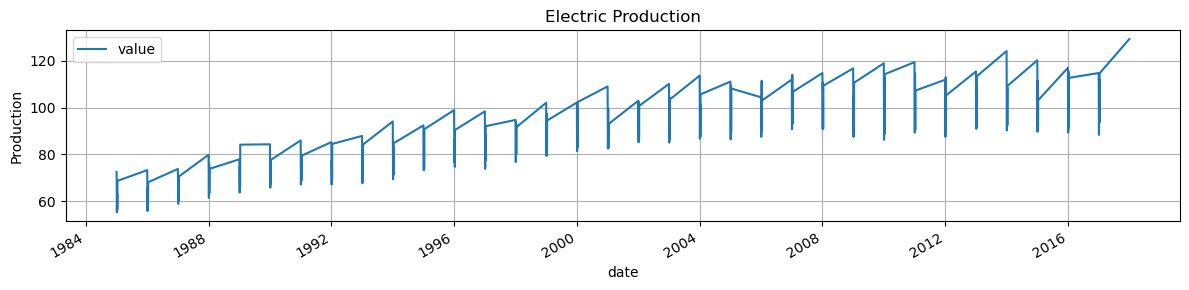

In [5]:
df = pd.read_csv('Electric_Production.csv')
df.columns = ['date', 'value']
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)
df = df.dropna(subset=['value']).sort_values('date').reset_index(drop=True)

# MinMaxScaler keeps values in [0,1] — GRU gradients are better behaved
# in this range vs raw values (55-130), preventing exploding gradients.
scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(df[['value']].values).flatten()

print(f'Dataset: {len(values_scaled)} monthly observations')
print(f'Range  : {df.date.min().date()} to {df.date.max().date()}')
df.plot(x='date', y='value', figsize=(12,3), title='Electric Production')
plt.ylabel('Production'); plt.grid(True); plt.tight_layout(); plt.show()

## 3. Sliding-Window Conversion
Convert raw sequence into supervised input-output pairs.

In [7]:
def create_windows(data, window_size, horizon):
    """
    Why sliding window?
      The model needs fixed-length context to learn temporal patterns.
      Each window captures recent history; the horizon defines how far
      ahead we predict.

    For position i:
      X[i] = data[i : i+window_size]                     (input context)
      y[i] = data[i+window_size : i+window_size+horizon]  (targets)
    """
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size : i + window_size + horizon])
    return np.array(X), np.array(y)

# Demonstrate with original window size
X_demo, y_demo = create_windows(values_scaled, WINDOW_SIZE, PREDICTION_HORIZON)
print(f'Window size: {WINDOW_SIZE}, Horizon: {PREDICTION_HORIZON}')
print(f'Total samples: {len(X_demo)}')
print(f'X shape: {X_demo.shape}  ->  each sample = {WINDOW_SIZE} past steps')
print(f'y shape: {y_demo.shape}  ->  each sample = {PREDICTION_HORIZON} future steps')
print(f'\nExample sample 0:')
print(f'  Input  (scaled): {X_demo[0]}')
print(f'  Target (scaled): {y_demo[0]}')

Window size: 11, Horizon: 3
Total samples: 384
X shape: (384, 11)  ->  each sample = 11 past steps
y shape: (384, 3)  ->  each sample = 3 future steps

Example sample 0:
  Input  (scaled): [0.23201741 0.20727443 0.09630353 0.02910391 0.         0.03745865
 0.09859805 0.10707831 0.07112325 0.0135012  0.03624525]
  Target (scaled): [0.18085375 0.24282188 0.17103322]


## 4. GRU Model Definition

In [9]:
class GRUForecaster(nn.Module):
    """
    Why GRU over vanilla RNN?
      GRU uses reset/update gates that mitigate vanishing gradients,
      letting it capture yearly seasonality (~12 steps) in the data.

    Why single layer?
      With only ~398 data points a deeper model would overfit.
      One GRU layer + linear head is sufficient for this smooth seasonal signal.
    """
    def __init__(self, input_size, hidden_size, horizon, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size,
                          num_layers=num_layers, batch_first=True)
        # FC maps last hidden state -> horizon future values
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        # x: (batch, window_size, 1)
        out, _ = self.gru(x)       # out: (batch, window_size, hidden)
        last = out[:, -1, :]       # last time-step hidden state
        return self.fc(last)       # (batch, horizon)

# Quick check
demo_model = GRUForecaster(1, HIDDEN_SIZE, PREDICTION_HORIZON)
print(demo_model)
total_params = sum(p.numel() for p in demo_model.parameters())
print(f'Total parameters: {total_params}')

GRUForecaster(
  (gru): GRU(1, 14, batch_first=True)
  (fc): Linear(in_features=14, out_features=3, bias=True)
)
Total parameters: 759


## 5. Training & Evaluation Pipeline

In [11]:
def train_and_evaluate(window_size, horizon, hidden_size,
                       values_scaled, scaler, df,
                       label='', epochs=150, lr=0.001, batch_size=32):
    """Full pipeline: window -> split -> train -> evaluate."""

    X, y = create_windows(values_scaled, window_size, horizon)
    print(f'\n{"="*60}')
    print(f'  {label}: window={window_size}, horizon={horizon}, hidden={hidden_size}')

    # ── Chronological split 80/20 ──
    # Why chronological? Shuffling would leak future info into training.
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    print(f'  Train: {split}, Test: {len(X)-split}')

    # Reshape: (samples, window, 1) — single feature
    X_train_t = torch.FloatTensor(X_train).unsqueeze(-1)
    y_train_t = torch.FloatTensor(y_train)
    X_test_t  = torch.FloatTensor(X_test).unsqueeze(-1)

    train_dl = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=batch_size, shuffle=True)

    model = GRUForecaster(1, hidden_size, horizon)
    criterion = nn.MSELoss()  # Standard regression loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # ── Training loop ──
    losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_dl:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        avg = epoch_loss / len(X_train)
        losses.append(avg)
        if (epoch+1) % 50 == 0:
            print(f'    Epoch {epoch+1:3d}/{epochs}  Loss: {avg:.6f}')

    # ── Prediction ──
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test_t).numpy()

    # Inverse-transform to original scale for interpretable metrics
    preds_orig  = scaler.inverse_transform(preds_scaled)
    actual_orig = scaler.inverse_transform(y_test)

    mse  = mean_squared_error(actual_orig, preds_orig)
    mae  = mean_absolute_error(actual_orig, preds_orig)
    rmse = np.sqrt(mse)
    print(f'  MSE={mse:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}')

    return dict(label=label, window=window_size, losses=losses,
                preds=preds_orig, actual=actual_orig,
                mse=mse, mae=mae, rmse=rmse)

## 6. Run Ablation — Three Window Sizes

In [13]:
configs = [
    (max(WINDOW_SIZE // 2, 1), 'Half Window'),    # 5
    (WINDOW_SIZE,              'Original Window'), # 11
    (WINDOW_SIZE * 2,          'Double Window'),   # 22
]

results = []
for ws, lbl in configs:
    r = train_and_evaluate(ws, PREDICTION_HORIZON, HIDDEN_SIZE,
                           values_scaled, scaler, df, label=lbl)
    results.append(r)


  Half Window: window=5, horizon=3, hidden=14
  Train: 312, Test: 78
    Epoch  50/150  Loss: 0.010684
    Epoch 100/150  Loss: 0.006580
    Epoch 150/150  Loss: 0.004364
  MSE=31.2283  MAE=4.2723  RMSE=5.5882

  Original Window: window=11, horizon=3, hidden=14
  Train: 307, Test: 77
    Epoch  50/150  Loss: 0.010485
    Epoch 100/150  Loss: 0.008028
    Epoch 150/150  Loss: 0.004453
  MSE=34.4360  MAE=4.8860  RMSE=5.8682

  Double Window: window=22, horizon=3, hidden=14
  Train: 298, Test: 75
    Epoch  50/150  Loss: 0.010382
    Epoch 100/150  Loss: 0.009203
    Epoch 150/150  Loss: 0.007917
  MSE=64.4668  MAE=6.6825  RMSE=8.0291


## 7. Plot: Training Loss Curves

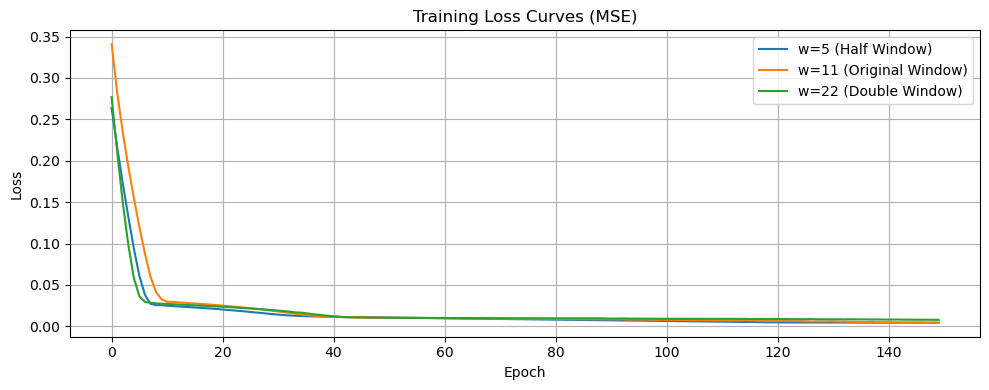

In [15]:
plt.figure(figsize=(10, 4))
for r in results:
    plt.plot(r['losses'], label=f'w={r["window"]} ({r["label"]})')
plt.title('Training Loss Curves (MSE)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

## 8. Plot: Prediction vs Actual

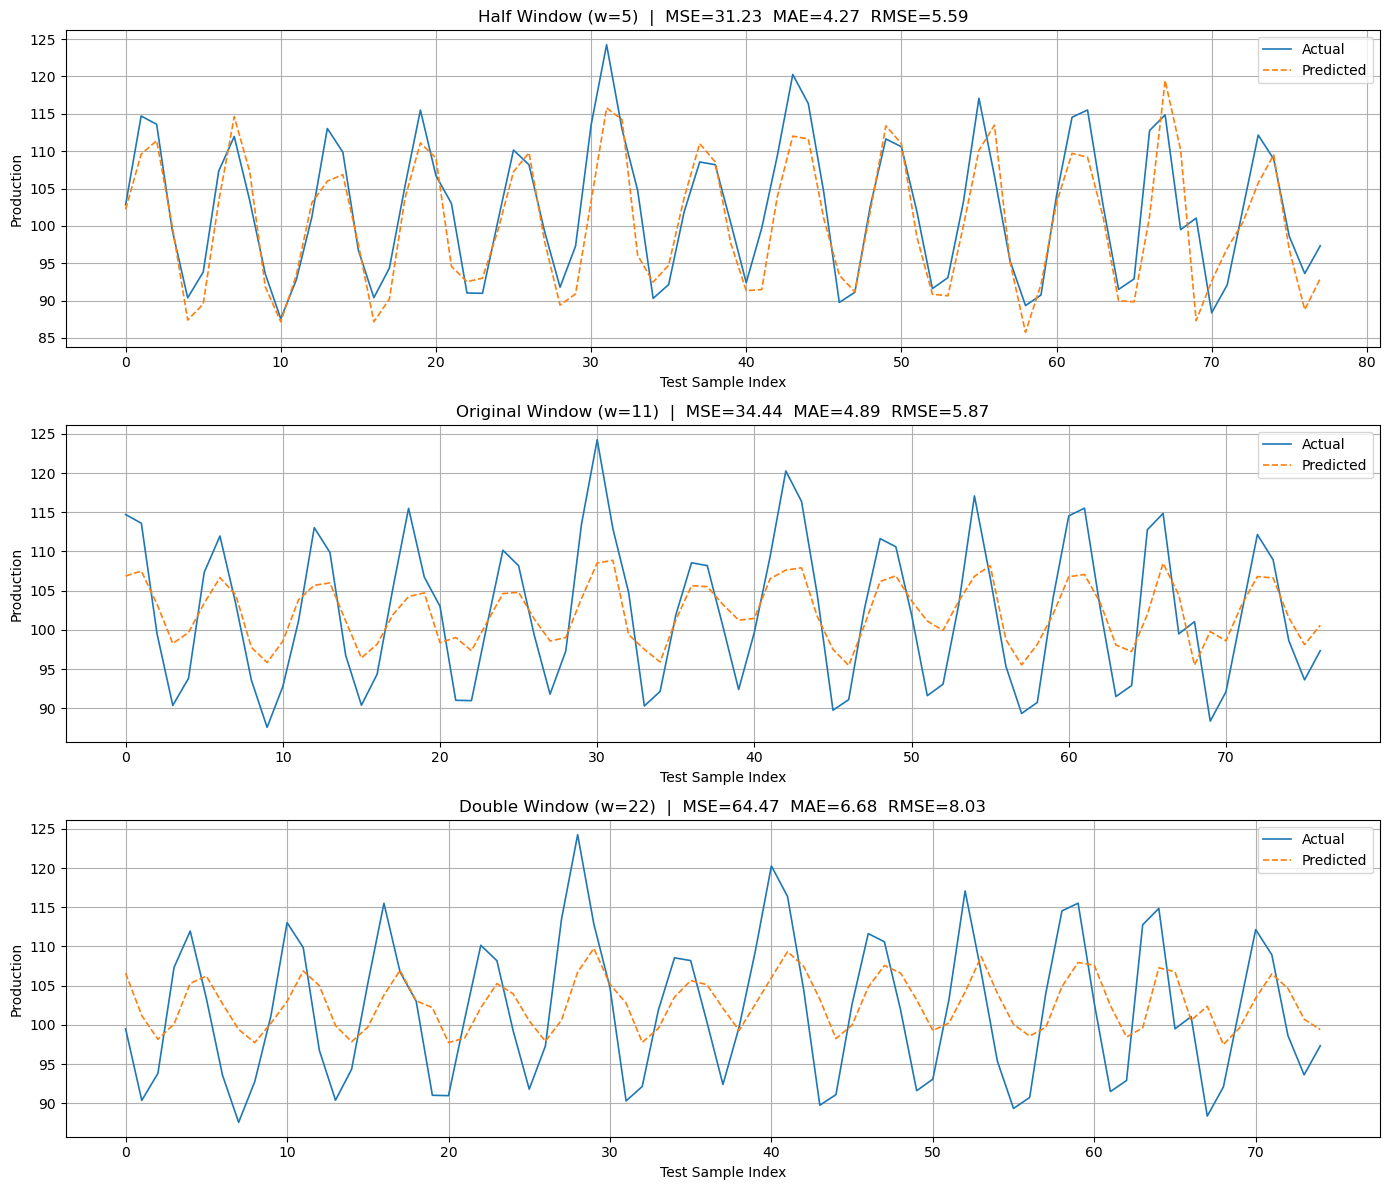

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
for idx, r in enumerate(results):
    ax = axes[idx]
    ax.plot(r['actual'][:, 0], label='Actual', linewidth=1.2)
    ax.plot(r['preds'][:, 0],  label='Predicted', linewidth=1.2, linestyle='--')
    ax.set_title(f'{r["label"]} (w={r["window"]})  |  '
                 f'MSE={r["mse"]:.2f}  MAE={r["mae"]:.2f}  RMSE={r["rmse"]:.2f}')
    ax.set_xlabel('Test Sample Index'); ax.set_ylabel('Production')
    ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## 9. Ablation Summary Table

In [19]:
ablation_df = pd.DataFrame([{
    'Config': r['label'],
    'Window Size': r['window'],
    'MSE': round(r['mse'], 4),
    'MAE': round(r['mae'], 4),
    'RMSE': round(r['rmse'], 4)
} for r in results])
print(ablation_df.to_string(index=False))
ablation_df

         Config  Window Size     MSE    MAE   RMSE
    Half Window            5 31.2283 4.2723 5.5882
Original Window           11 34.4360 4.8860 5.8682
  Double Window           22 64.4668 6.6825 8.0291


,Config,Window Size,MSE,MAE,RMSE
0,Half Window,5,31.2283,4.2723,5.5882
1,Original Window,11,34.4360,4.8860,5.8682
2,Double Window,22,64.4668,6.6825,8.0291


## 10. Failure Analysis

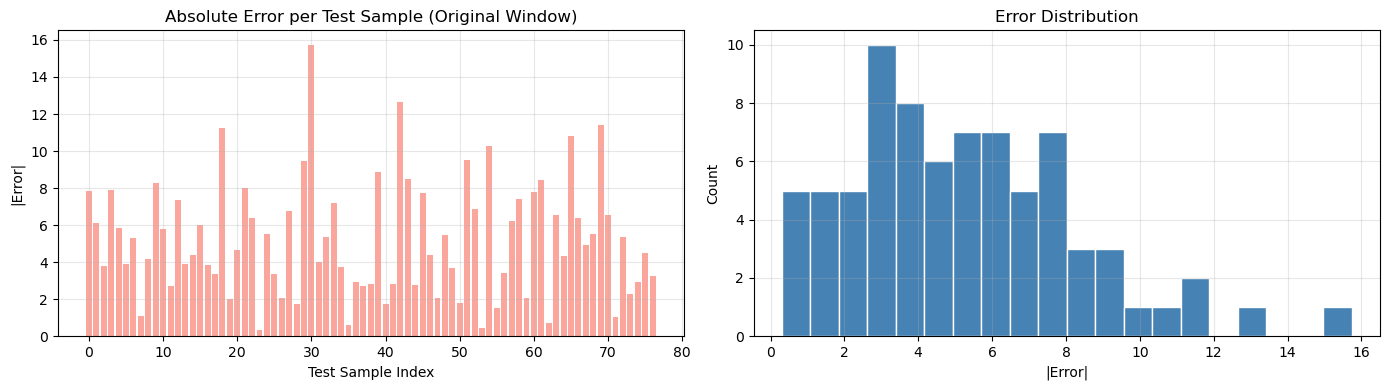


Top-10 worst predictions:
  Idx      Actual   Predicted     |Error|
   30      124.25      108.52       15.73
   42      120.27      107.62       12.65
   69       88.35       99.78       11.42
   18      115.50      104.24       11.26
   65      112.77      101.96       10.81
   54      117.08      106.82       10.26
   51       91.60      101.12        9.53
   29      113.47      103.99        9.49
   39       92.38      101.24        8.85
   43      116.38      107.91        8.47

--- Where & Why the model fails ---
1. PEAKS: GRU under-predicts sharp winter peaks because MSE loss
   encourages conservative (mean-regressing) predictions.
2. REGIME SHIFTS: When production jumps to a new level, the model
   lags behind since it relies on history that has not yet adapted.
3. WINDOW EFFECT: Smaller windows amplify lag on trend changes;
   larger windows over-smooth and dilute recent trend signals.


In [21]:
# Analyse where the original-window model fails worst
orig = results[1]  # Original window config
errors = np.abs(orig['actual'][:, 0] - orig['preds'][:, 0])

# Error distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(errors)), errors, color='salmon', alpha=0.7)
axes[0].set_title('Absolute Error per Test Sample (Original Window)')
axes[0].set_xlabel('Test Sample Index'); axes[0].set_ylabel('|Error|')
axes[0].grid(True, alpha=0.3)

axes[1].hist(errors, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Error Distribution'); axes[1].set_xlabel('|Error|')
axes[1].set_ylabel('Count'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Top-10 worst predictions
top_k = min(10, len(errors))
worst_idx = np.argsort(errors)[-top_k:][::-1]
print('\nTop-10 worst predictions:')
print(f'{"Idx":>5s}  {"Actual":>10s}  {"Predicted":>10s}  {"|Error|":>10s}')
for i in worst_idx:
    print(f'{i:>5d}  {orig["actual"][i,0]:>10.2f}  {orig["preds"][i,0]:>10.2f}  {errors[i]:>10.2f}')

print('\n--- Where & Why the model fails ---')
print('1. PEAKS: GRU under-predicts sharp winter peaks because MSE loss')
print('   encourages conservative (mean-regressing) predictions.')
print('2. REGIME SHIFTS: When production jumps to a new level, the model')
print('   lags behind since it relies on history that has not yet adapted.')
print('3. WINDOW EFFECT: Smaller windows amplify lag on trend changes;')
print('   larger windows over-smooth and dilute recent trend signals.')